In [20]:
import pandas as pd, numpy as np

matches = pd.read_csv('uefa/data/matches.csv')
mt      = pd.read_csv('uefa/data/match_teams.csv')
att     = pd.read_csv('uefa/data/attempts_at_goal.csv')
lb      = pd.read_csv('uefa/data/player_line_breaks.csv')

print(att['outcome'].value_counts())
print(mt['home_away'].unique())
print(matches[['match_id','match_number','date','group']].head())
print(matches['group'].unique())

outcome
Off Target                                826
On Target - Saved                         564
Incomplete - Blocked                      435
On Target - Goal                          288
Deflected Off Target - Defensive Event    207
                                         ... 
Nico OREILLY Incomplete                     1
Pedro PORRO Incomplete                      1
Eberechi EZE Incomplete                     1
Fredrik AURSNES Incomplete                  1
Bukayo SAKA On Target - Goal Prevented      1
Name: count, Length: 98, dtype: int64
<StringArray>
['home', 'away']
Length: 2, dtype: str
            match_id  match_number          date    group
0  2026-M001-MEX-RSA             1  11 June 2026  Group A
1  2026-M002-KOR-CZE             2  11 June 2026  Group A
2  2026-M003-CAN-BIH             3  12 June 2026  Group B
3  2026-M004-USA-PAR             4  12 June 2026  Group D
4  2026-M005-HAI-SCO             5  13 June 2026  Group C
<StringArray>
[     'Group A',      'Group B', 

In [21]:
ON_TARGET = ['Off Target', 'On Target - Saved', 'Incomplete - Blocked', 'On Target - Goal', 'Deflected Off Target - Defensive Event']
matches['date'] = pd.to_datetime(matches['date'])

tm = mt.merge(matches[['match_id','match_number','date','group']], on='match_id')
tm['goals_for'] = tm['score']
tm['goals_against'] = tm.groupby('match_id')['score'].transform('sum') - tm['score']

a = att.assign(on_t=att['outcome'].isin(ON_TARGET).astype(int)) \
       .groupby(['match_id','match_team_id']).agg(attempts=('event_id','count'),
                                                  on_target=('on_t','sum')).reset_index()
l = lb.groupby(['match_id','match_team_id']).agg(lb_att=('line_breaks_attempted','sum'),
                                                 lb_cmp=('line_breaks_completed','sum')).reset_index()

tm = tm.merge(a, on=['match_id','match_team_id'], how='left') \
       .merge(l, on=['match_id','match_team_id'], how='left')
tm[['attempts','on_target','lb_att','lb_cmp']] = tm[['attempts','on_target','lb_att','lb_cmp']].fillna(0)
tm.shape

(208, 15)

In [22]:
tm = tm.sort_values(['team_id','match_number']).reset_index(drop=True)
g = tm.groupby('team_id')

for c in ['goals_for','goals_against','attempts','on_target','lb_att']:
    tm[c+'_prior'] = g[c].transform(lambda s: s.shift().expanding().mean())

tm['rest_days'] = g['date'].diff().dt.days
tm['is_knockout'] = tm['group'].isna().astype(int)   # adjust if knockouts are labelled differently
tm['team_is_host'] = tm['team_name'].isin(['United States','USA','Mexico','Canada']).astype(int)

# first match of each team has no history -> fill with tournament average
for c in [x for x in tm.columns if x.endswith('_prior')] + ['rest_days']:
    tm[c] = tm[c].fillna(tm[c].mean())

In [23]:
ext = pd.read_csv('uefa/data/external.csv').drop_duplicates('team_id')
ext_cols = [c for c in ext.columns if c not in ('team_name',)]

# drop any previously merged external columns (avoids _x/_y duplicates), then re-merge
tm = tm.drop(columns=[c for c in ext_cols if c != 'team_id' and c in tm.columns], errors='ignore')
tm = tm.drop(columns=[c for c in tm.columns if c.endswith(('_x','_y'))], errors='ignore')
tm = tm.merge(ext[ext_cols], on='team_id', how='left')
tm['log_squad_value'] = np.log(tm['squad_value_meur'])

tm = tm.drop_duplicates('match_team_id').reset_index(drop=True)
print('tm shape:', tm.shape)           # expect 208 rows

h  = tm[tm.home_away=='home'].set_index('match_id')
aw = tm[tm.home_away=='away'].set_index('match_id')
print(len(h), len(aw), h.index.is_unique, aw.index.is_unique)   # expect 104 104 True True

tm shape: (208, 32)
104 104 True True


In [24]:
h  = tm[tm.home_away=='home'].set_index('match_id')
aw = tm[tm.home_away=='away'].set_index('match_id')

d1 = pd.DataFrame(index=h.index)
d1['goal_diff']            = h['goals_for'] - aw['goals_for']        # TARGET (home - away)
d1['elo_diff']             = h['elo'] - aw['elo']
d1['squad_age_diff']       = h['squad_avg_age'] - aw['squad_avg_age']
d1['gf_prior_diff']        = h['goals_for_prior'] - aw['goals_for_prior']
d1['ga_prior_diff']        = h['goals_against_prior'] - aw['goals_against_prior']
d1['on_target_prior_diff'] = h['on_target_prior'] - aw['on_target_prior']
d1['lb_prior_diff']        = h['lb_att_prior'] - aw['lb_att_prior']
d1['rest_days_diff']       = h['rest_days'] - aw['rest_days']
d1['is_knockout']          = h['is_knockout']
d1 = d1.reset_index()

feat21 = ['elo_diff','squad_age_diff','gf_prior_diff','ga_prior_diff',
          'on_target_prior_diff','lb_prior_diff','rest_days_diff','is_knockout']
assert len(feat21) == 8
print(d1.shape)                       # (104, 10)
print(d1.isna().sum().sum(), 'missing values')
d1.to_csv('uefa/data/Dataset_LR_2_1.csv', index=False)
d1.describe().T

(104, 10)
0 missing values


,count,mean,std,min,25%,50%,75%,max
goal_diff,104.0,0.480769,2.024034,-4.0,-1.000000,0.00,2.000000,6.0
elo_diff,104.0,69.855769,251.032177,-470.0,-133.250000,77.50,240.250000,581.0
squad_age_diff,104.0,-0.291346,1.658816,-4.9,-1.325000,-0.35,0.800000,3.9
gf_prior_diff,104.0,0.069345,1.337539,-4.5,-0.500000,0.00,0.833333,6.0
ga_prior_diff,104.0,-0.163897,1.233788,-6.0,-0.687500,0.00,0.333333,3.0
on_target_prior_diff,104.0,1.315270,5.698318,-11.0,-1.541667,0.00,3.541667,23.0
lb_prior_diff,104.0,6.981822,24.672330,-59.0,-4.150000,0.00,18.333333,93.5
rest_days_diff,104.0,0.115385,0.988356,-6.0,0.000000,0.00,0.000000,6.0
is_knockout,104.0,0.000000,0.000000,0.0,0.000000,0.00,0.000000,0.0


In [25]:
tm['is_knockout'] = (tm['match_number'] > 72).astype(int)
print(tm.groupby('is_knockout')['match_id'].nunique())     # expect 72 and 32

# rebuild h / aw and d1
h  = tm[tm.home_away=='home'].set_index('match_id')
aw = tm[tm.home_away=='away'].set_index('match_id')
d1['is_knockout'] = d1['match_id'].map(h['is_knockout'])
print(d1['is_knockout'].value_counts())

is_knockout
0    72
1    32
Name: match_id, dtype: int64
is_knockout
0    72
1    32
Name: count, dtype: int64


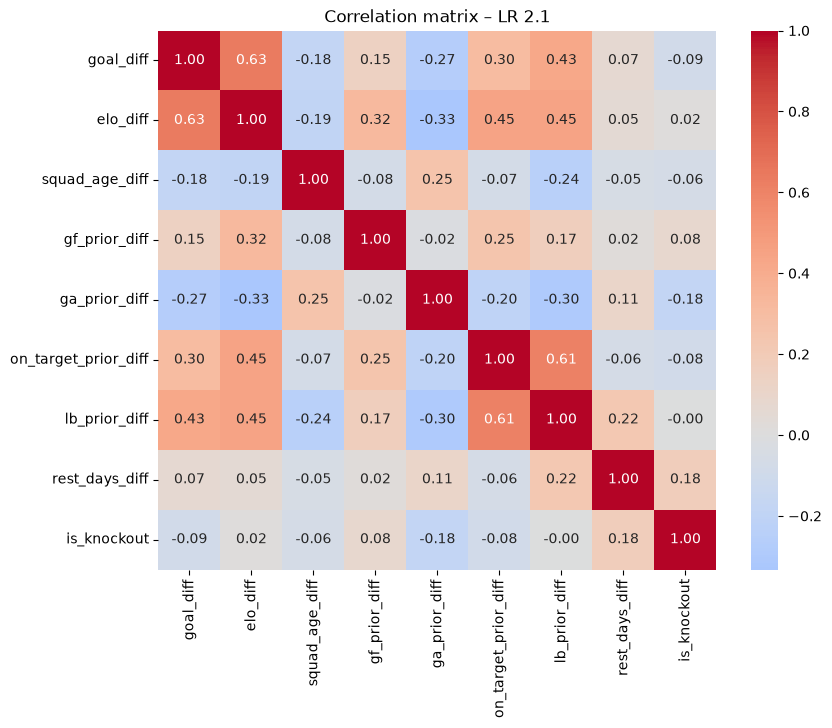

elo_diff                1.52
squad_age_diff          1.13
gf_prior_diff           1.16
ga_prior_diff           1.33
on_target_prior_diff    1.88
lb_prior_diff           2.06
rest_days_diff          1.22
is_knockout             1.11
Name: VIF, dtype: float64


In [26]:
import matplotlib.pyplot as plt, seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

plt.figure(figsize=(9,7))
sns.heatmap(d1[['goal_diff']+feat21].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix – LR 2.1'); plt.show()

Xc = sm.add_constant(d1[feat21])
vif = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
                index=feat21, name='VIF')
print(vif.round(2))

## 2.1

In [27]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X, y = d1[feat21], d1['goal_diff']

ols = sm.OLS(y, sm.add_constant(X)).fit()
print(ols.summary())

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression().fit(Xtr, ytr)
pred = lr.predict(Xte)
print('\nHold-out  R2 :', round(r2_score(yte, pred), 3))
print('Hold-out RMSE:', round(mean_squared_error(yte, pred)**0.5, 3))
print('Hold-out  MAE:', round(mean_absolute_error(yte, pred), 3))

cv = KFold(n_splits=5, shuffle=True, random_state=42)
print('5-fold CV R2 :', round(cross_val_score(LinearRegression(), X, y, cv=cv, scoring='r2').mean(), 3))

base_rmse = (((yte - ytr.mean())**2).mean())**0.5
print('Baseline RMSE (predict mean):', round(base_rmse, 3))

                            OLS Regression Results                            
Dep. Variable:              goal_diff   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     9.537
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           1.33e-09
Time:                        17:35:18   Log-Likelihood:                -189.74
No. Observations:                 104   AIC:                             397.5
Df Residuals:                      95   BIC:                             421.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.2116 

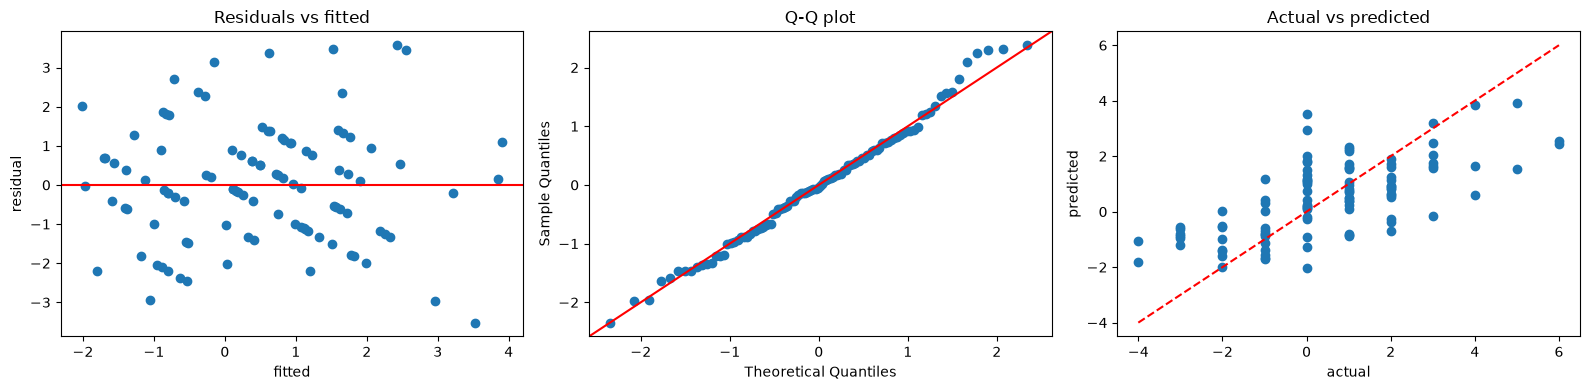

                        coef  p_value
const                 0.2116   0.2808
elo_diff              0.0046   0.0000
squad_age_diff       -0.0267   0.7876
gf_prior_diff        -0.0605   0.6289
ga_prior_diff        -0.0828   0.5685
on_target_prior_diff -0.0306   0.4129
lb_prior_diff         0.0167   0.0663
rest_days_diff        0.0269   0.8766
is_knockout          -0.4882   0.1684


In [28]:
resid = ols.resid
fig, ax = plt.subplots(1, 3, figsize=(16,4))
ax[0].scatter(ols.fittedvalues, resid); ax[0].axhline(0, color='r')
ax[0].set(title='Residuals vs fitted', xlabel='fitted', ylabel='residual')
sm.qqplot(resid, line='45', fit=True, ax=ax[1]); ax[1].set_title('Q-Q plot')
ax[2].scatter(y, ols.fittedvalues); ax[2].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
ax[2].set(title='Actual vs predicted', xlabel='actual', ylabel='predicted')
plt.tight_layout(); plt.show()

coef = pd.DataFrame({'coef': ols.params, 'p_value': ols.pvalues}).round(4)
print(coef)

## 2.2

In [29]:
opp = tm[['match_id','team_id','elo','log_squad_value','goals_against_prior']].rename(
    columns={'team_id':'opp_id','elo':'opp_elo',
             'log_squad_value':'opp_log_squad_value',
             'goals_against_prior':'opp_ga_prior'})

d2 = tm.merge(opp, on='match_id')
d2 = d2[d2.team_id != d2.opp_id].copy()

d2 = d2.rename(columns={'elo':'team_elo',
                        'goals_for_prior':'team_gf_prior',
                        'attempts_prior':'team_attempts_prior',
                        'log_squad_value':'team_log_squad_value'})
d2['goals'] = d2['goals_for']

feat22 = ['team_elo','opp_elo','team_gf_prior','opp_ga_prior',
          'team_attempts_prior','team_log_squad_value','opp_log_squad_value','team_is_host']
assert len(feat22) == 8

d2 = d2[['match_id','team_id','goals'] + feat22].reset_index(drop=True)
print(d2.shape)                          # expect (208, 11)
print(d2.isna().sum().sum(), 'missing values')
print('host rows:', d2['team_is_host'].sum(), '(should be > 0)')
d2.to_csv('uefa/data/Dataset_LR_2_2.csv', index=False)
d2.describe().T

(208, 11)
0 missing values
host rows: 15 (should be > 0)


,count,mean,std,min,25%,50%,75%,max
goals,208.0,1.480769,1.393434,0.000000,0.000000,1.000000,2.000000,7.000000
team_elo,208.0,1822.235577,181.292268,1421.000000,1696.000000,1833.000000,1938.000000,2157.000000
opp_elo,208.0,1822.235577,181.292268,1421.000000,1696.000000,1833.000000,1938.000000,2157.000000
team_gf_prior,208.0,1.726086,0.971428,0.000000,1.000000,1.726086,2.000000,7.000000
opp_ga_prior,208.0,1.261711,0.942754,0.000000,0.787500,1.000000,1.333333,7.000000
team_attempts_prior,208.0,13.246384,4.731437,3.000000,10.383333,13.246384,15.000000,31.000000
team_log_squad_value,208.0,5.536482,1.277254,2.809403,4.941085,5.594711,6.472501,7.352441
opp_log_squad_value,208.0,5.536482,1.277254,2.809403,4.941085,5.594711,6.472501,7.352441
team_is_host,208.0,0.072115,0.259303,0.000000,0.000000,0.000000,0.000000,1.000000


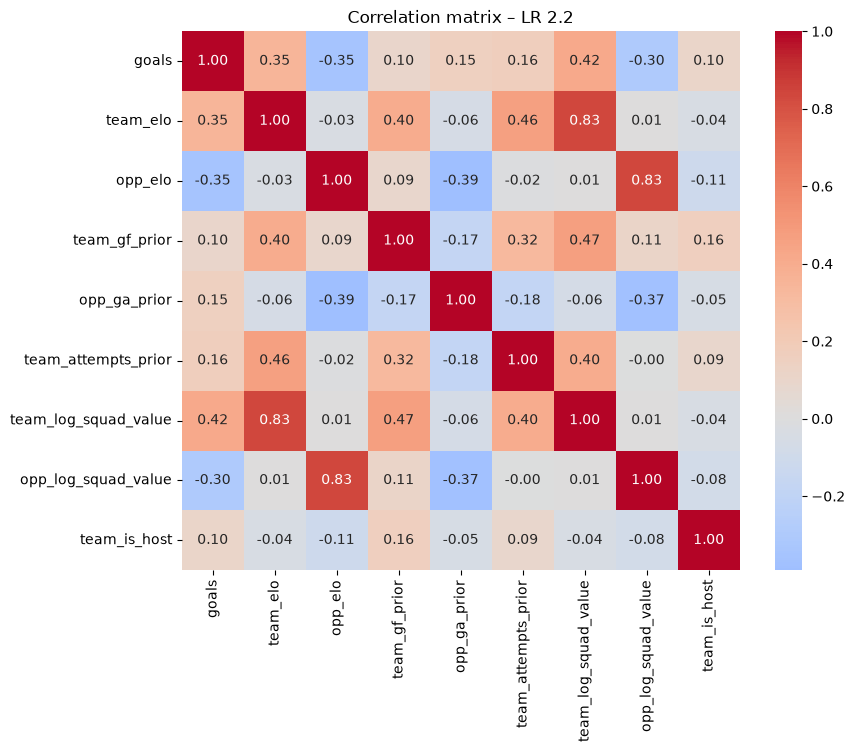

team_elo                3.56
opp_elo                 3.45
team_gf_prior           1.41
opp_ga_prior            1.26
team_attempts_prior     1.36
team_log_squad_value    3.59
opp_log_squad_value     3.36
team_is_host            1.08
Name: VIF, dtype: float64


In [30]:
plt.figure(figsize=(9,7))
sns.heatmap(d2[['goals']+feat22].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix – LR 2.2'); plt.show()

Xc = sm.add_constant(d2[feat22].astype(float), has_constant='add')
print(pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
                index=feat22, name='VIF').round(2))

In [31]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

X, y, grp = d2[feat22], d2['goals'], d2['match_id']

# full-data OLS; standard errors clustered by match because the two rows of a match are related
ols2 = sm.OLS(y, sm.add_constant(X)).fit(cov_type='cluster', cov_kwds={'groups': pd.factorize(grp)[0]})
print(ols2.summary())

# hold-out split by match
tr, te = next(GroupShuffleSplit(test_size=0.2, random_state=42).split(X, y, grp))
lr2 = LinearRegression().fit(X.iloc[tr], y.iloc[tr])
p = lr2.predict(X.iloc[te])
print('\nHold-out  R2 :', round(r2_score(y.iloc[te], p), 3))
print('Hold-out RMSE:', round(mean_squared_error(y.iloc[te], p)**0.5, 3))
print('Hold-out  MAE:', round(mean_absolute_error(y.iloc[te], p), 3))
print('Baseline RMSE:', round(((y.iloc[te] - y.iloc[tr].mean())**2).mean()**0.5, 3))

cv_r2 = cross_val_score(LinearRegression(), X, y, cv=GroupKFold(5), groups=grp, scoring='r2')
print('5-fold grouped CV R2:', round(cv_r2.mean(), 3))

                            OLS Regression Results                            
Dep. Variable:                  goals   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     12.23
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           3.66e-12
Time:                        17:35:21   Log-Likelihood:                -324.12
No. Observations:                 208   AIC:                             666.2
Df Residuals:                     199   BIC:                             696.3
Df Model:                           8                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    3.3620 

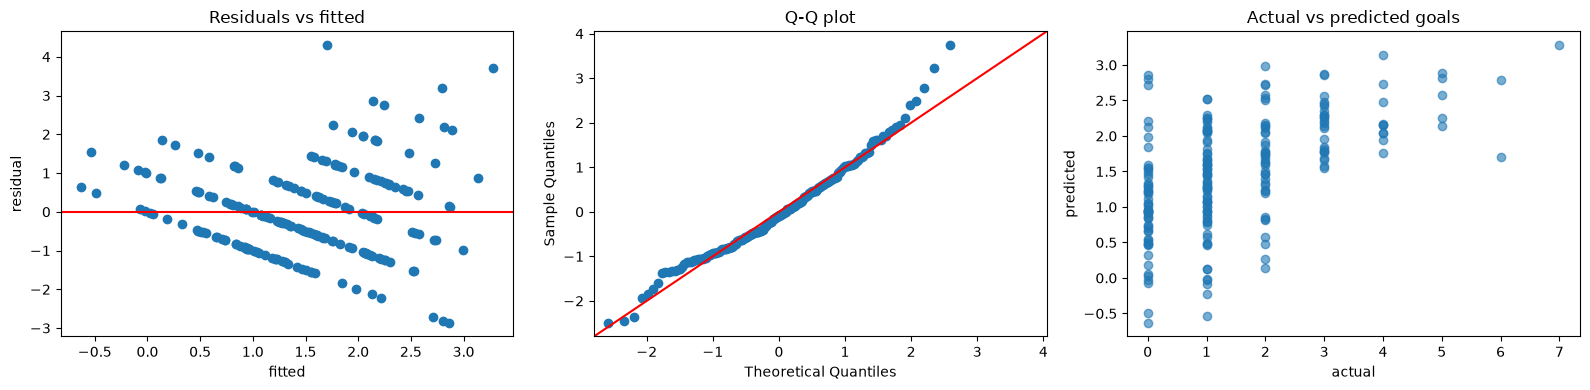

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
ax[0].scatter(ols2.fittedvalues, ols2.resid); ax[0].axhline(0, color='r')
ax[0].set(title='Residuals vs fitted', xlabel='fitted', ylabel='residual')
sm.qqplot(ols2.resid, line='45', fit=True, ax=ax[1]); ax[1].set_title('Q-Q plot')
ax[2].scatter(y, ols2.fittedvalues, alpha=.6)
ax[2].set(title='Actual vs predicted goals', xlabel='actual', ylabel='predicted')
plt.tight_layout(); plt.show()

In [33]:
glm = sm.GLM(y, sm.add_constant(X), family=sm.families.Poisson()).fit(
    cov_type='cluster', cov_kwds={'groups': pd.factorize(grp)[0]})
print(glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                  208
Model:                            GLM   Df Residuals:                      199
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -290.37
Date:                Fri, 09 Oct 2026   Deviance:                       200.82
Time:                        17:35:23   Pearson chi2:                     170.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3572
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.2924 